In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
)

In [2]:
from IPython.display import HTML, display

bmw_m3_url = "https://i.ytimg.com/vi/_HJXb_i4nxU/maxresdefault.jpg"
bm2_m5_url = "https://s.yimg.com/ny/api/res/1.2/K.4rgz5llYrJS6OGONrjpA--/YXBwaWQ9aGlnaGxhbmRlcjt3PTEyNDI7aD02OTk-/https://media.zenfs.com/en/the_drive_634/08a009aa430b59590ddeec0e177b49be"

html = f"""
<div style="display:flex; justify-content:center; gap:40px;">
  <div style="text-align:center;">
    <img src="{bmw_m3_url}" style="width:520px; height:260px; object-fit:cover;"><br>
    <b>M3 2025</b>
  </div>
  
  <div style="text-align:center;">
    <img src="{bm2_m5_url}" style="width:520px; height:260px; object-fit:cover;"><br>
    <b>M5 2025</b>
  </div>
</div>
"""

display(HTML(html))

In [3]:
bmw = pd.read_csv('bmw_dataset.csv')

print("DataFrame Head:")
print(bmw.head())
print("\nDataFrame Info:")
bmw.info()


DataFrame Head:
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume  ... Cluster_DBSCAN  Cluster_Agglo  \
0      151748      98740          8300  ...              0              0   
1      121671      79219          3428  ...              0              0   
2       10991     113265          6994  ...              0              0   
3       27255      60971          4047  ...              0              1   
4      122131      49898          3080  ...              0              1   

   Anomaly_IF  Anomaly_LOF  Sales_

In [4]:
def plot_confusion_matrix_simple(cm, labels=("Negative", "Positive")):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=35)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


def summarize_grid(grid, model_name):
    row = {
        "model": model_name,
        "best_params": grid.best_params_,
        "best_cv_accuracy": round(grid.best_score_, 4),
    }
    return row

In [5]:
print(bmw.columns.tolist())

['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'Sales_Classification', 'Elasticity_Index', 'Revenue_Density', 'Fuel_Adoption_Velocity', 'Composite_Health_Score', 'Market_Saturation_Ratio', 'Consumer_Stickiness_Index', 'Lifecycle_HalfLife', 'Regional_Momentum', 'Brand_Reputation', 'Prestige_Index', 'Volatility_Index', 'Innovation_Shock_Index', 'Resilience_Factor', 'Cannibalization_Metric', 'Chaos_Metric', 'Cluster_KMeans', 'Cluster_DBSCAN', 'Cluster_Agglo', 'Anomaly_IF', 'Anomaly_LOF', 'Sales_Trend', 'CUSUM_Shock', 'Forecast_Hook', 'Rolling_Variance', 'Persistence_Index', 'Chaos_vs_Resilience']


In [6]:
X = bmw[["Year","Price_USD","Fuel_Adoption_Velocity","Sales_Volume","Revenue_Density","Lifecycle_HalfLife","Anomaly_LOF"]]

y =bmw["Anomaly_IF"]


print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())

print("Unique target values:", y.unique())  # substitui target_names
X.head()

Dataset shape: (50000, 7)
Class distribution:
Anomaly_IF
-1     2500
 1    47500
Name: count, dtype: int64
Unique target values: [ 1 -1]


,Year,Price_USD,Fuel_Adoption_Velocity,Sales_Volume,Revenue_Density,Lifecycle_HalfLife,Anomaly_LOF
0,2016,98740,0,8300,819542000,0,1
1,2013,79219,1,3428,271562732,6,1
2,2022,113265,1,6994,792175410,0,1
3,2024,60971,0,4047,246749637,8,1
4,2020,49898,0,3080,153685840,12,1


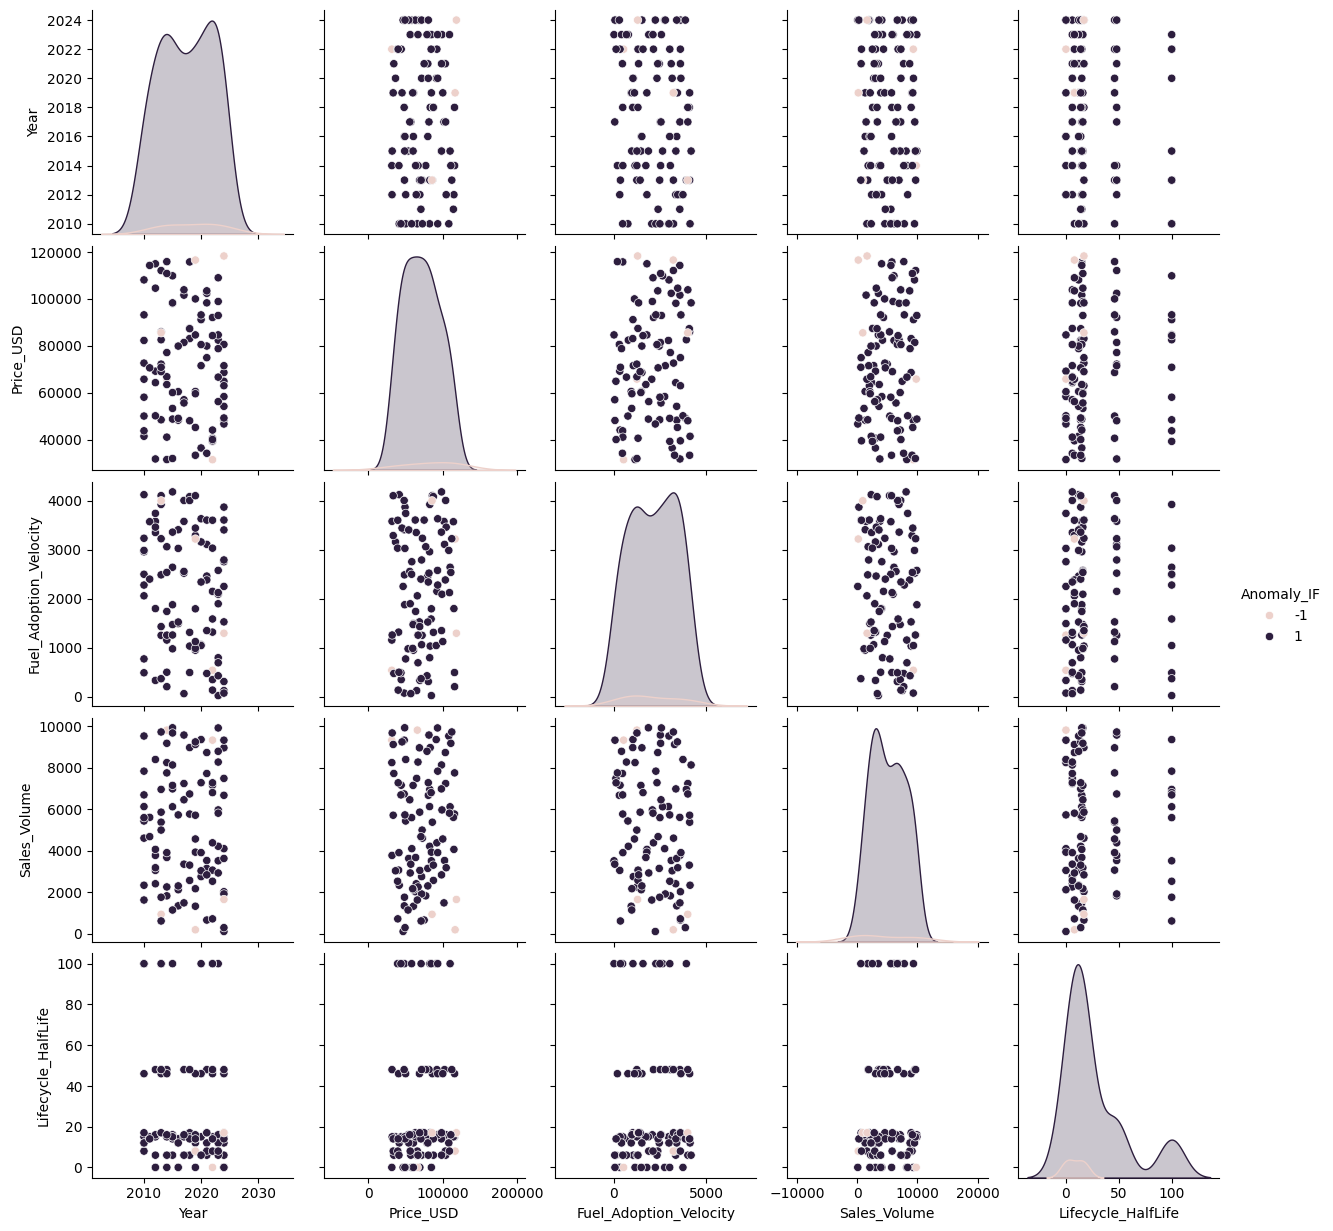

In [ ]:
df = X.copy()
df["Anomaly_IF"] = y
df_sample = df.sample(n=100, random_state=42)  
g = sns.pairplot(
    df_sample,
    vars=["Year","Price_USD","Fuel_Adoption_Velocity","Sales_Volume","Lifecycle_HalfLife"],
    hue="Anomaly_IF"
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (40000, 7)
Test shape:  (10000, 7)


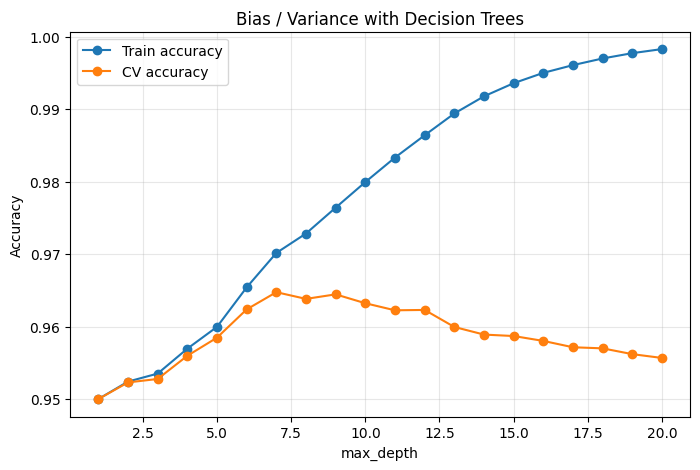

In [11]:
depths = range(1, 21)

train_scores = []
cv_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)

    scores = cross_validate(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    train_scores.append(scores["train_score"].mean())
    cv_scores.append(scores["test_score"].mean())

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, cv_scores, marker="o", label="CV accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Bias / Variance with Decision Trees")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

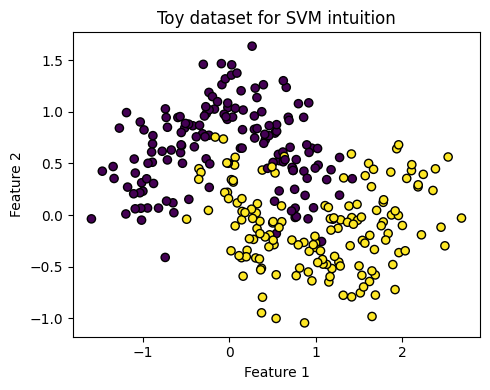

In [14]:
X_toy, y_toy = make_moons(n_samples=300, noise=0.25, random_state=42)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, edgecolor="k", s=35)
ax.set_title("Toy dataset for SVM intuition")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

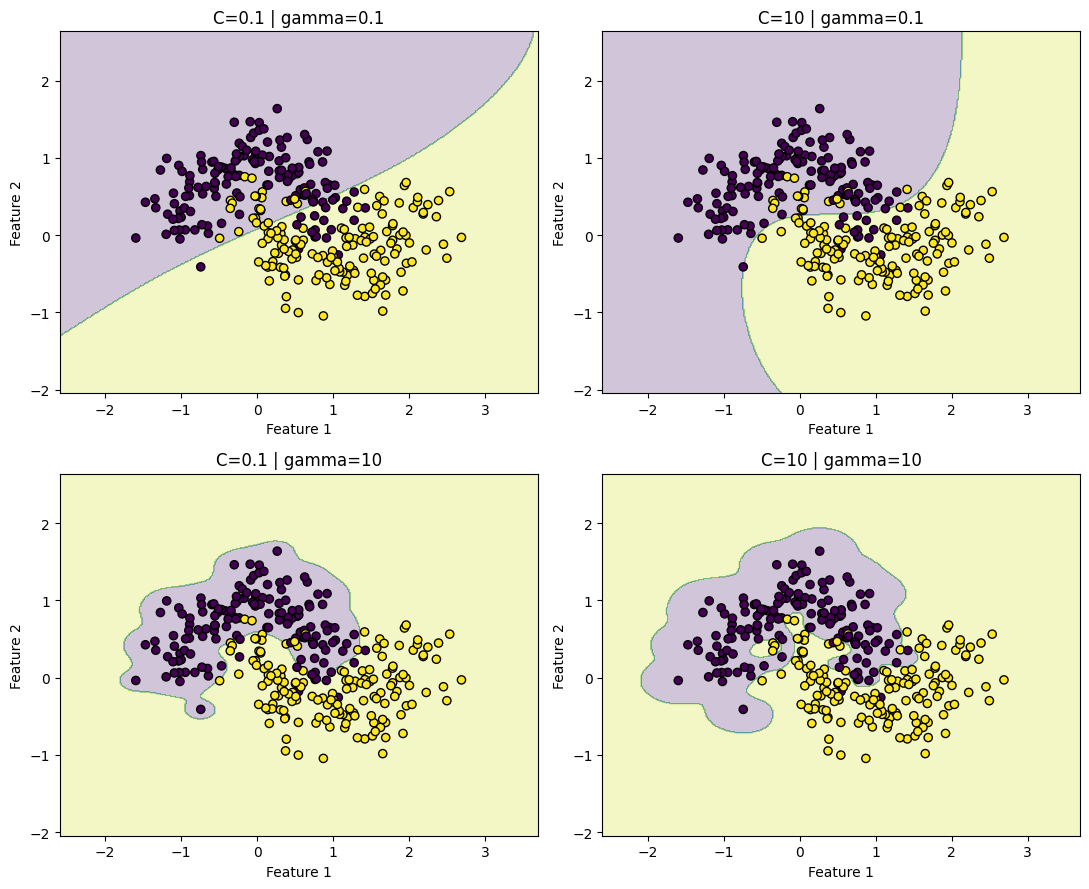

In [15]:
svm_configs = [
    {"C": 0.1, "gamma": 0.1},
    {"C": 10,  "gamma": 0.1},
    {"C": 0.1, "gamma": 10},
    {"C": 10,  "gamma": 10},
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, cfg in zip(axes, svm_configs):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=cfg["C"], gamma=cfg["gamma"]))  #RBF -> polynomial kernel → non-linear boundary
    ])
    model.fit(X_toy, y_toy)
    plot_decision_boundary(
        model,
        X_toy,
        y_toy,
        ax,
        title=f"C={cfg['C']} | gamma={cfg['gamma']}"
    )

plt.tight_layout()
plt.show()

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

comparison_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "roc_auc"],
        n_jobs=-1
    )

    comparison_rows.append({
        "model": name,
        "mean_cv_accuracy": scores["test_accuracy"].mean(),
        "std_cv_accuracy": scores["test_accuracy"].std(),
        "mean_cv_roc_auc": scores["test_roc_auc"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("mean_cv_accuracy", ascending=False)
comparison_df

,model,mean_cv_accuracy,std_cv_accuracy,mean_cv_roc_auc
2,Gradient Boosting,0.968325,0.001108,0.972189
0,Decision Tree,0.954925,0.002689,0.770224
1,SVM,0.953025,0.000726,0.797260


In [18]:
X_train_small = X.sample(n=1000, random_state=42)
y_train_small = y.loc[X_train_small.index]

tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    param_grid={
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [1, 2, 3],
    },
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train_small, y_train_small)
svm_grid.fit(X_train_small, y_train_small)
gb_grid.fit(X_train_small, y_train_small)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [19]:
tuned_summary = pd.DataFrame([
    summarize_grid(tree_grid, "Decision Tree"),
    summarize_grid(svm_grid, "SVM"),
    summarize_grid(gb_grid, "Gradient Boosting"),
]).sort_values("best_cv_accuracy", ascending=False)

tuned_summary

,model,best_params,best_cv_accuracy
2,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.954
0,Decision Tree,"{'max_depth': 4, 'min_samples_leaf': 1, 'min_s...",0.952
1,SVM,"{'svm__C': 0.01, 'svm__gamma': 0.001}",0.952


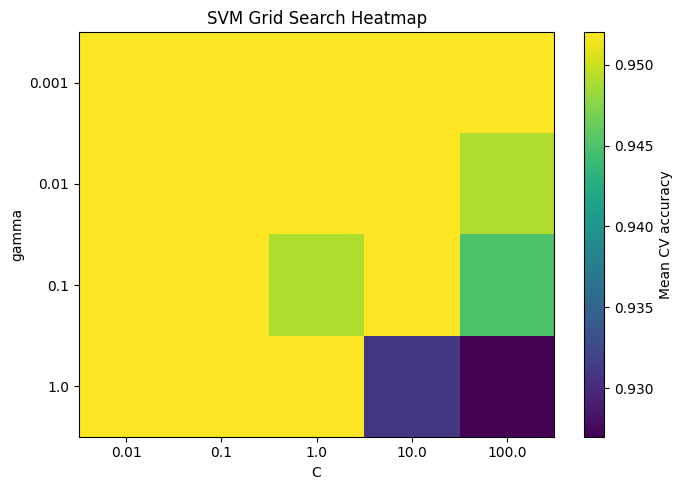

In [20]:
svm_results = pd.DataFrame(svm_grid.cv_results_)

heatmap_data = svm_results.pivot_table(
    values="mean_test_score",
    index="param_svm__gamma",
    columns="param_svm__C"
)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean CV accuracy")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("SVM Grid Search Heatmap")
plt.tight_layout()
plt.show()

In [21]:
all_grids = {
    "Decision Tree": tree_grid,
    "SVM": svm_grid,
    "Gradient Boosting": gb_grid,
}

best_model_name = max(all_grids, key=lambda name: all_grids[name].best_score_)
best_grid = all_grids[best_model_name]

print("Best model:", best_model_name)
print("Best CV accuracy:", round(best_grid.best_score_, 4))
print("Best parameters:", best_grid.best_params_)

Best model: Gradient Boosting
Best CV accuracy: 0.954
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [24]:
# Out-of-fold probabilities/scores on the training set
if best_model_name == "SVM":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train_small,
        y_train_small,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
elif best_model_name == "Gradient Boosting":
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train_small,
        y_train_small,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]
else:
    oof_scores = cross_val_predict(
        best_grid.best_estimator_,
        X_train_small,
        y_train_small,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for thr in thresholds:
    preds = (oof_scores >= thr).astype(int)
    f1_scores.append(f1_score(y_train_small, preds, average="weighted"))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Chosen threshold:", round(best_threshold, 3))
print("Best training OOF F1:", round(best_f1, 4))

Chosen threshold: 0.5
Best training OOF F1: 0.9292


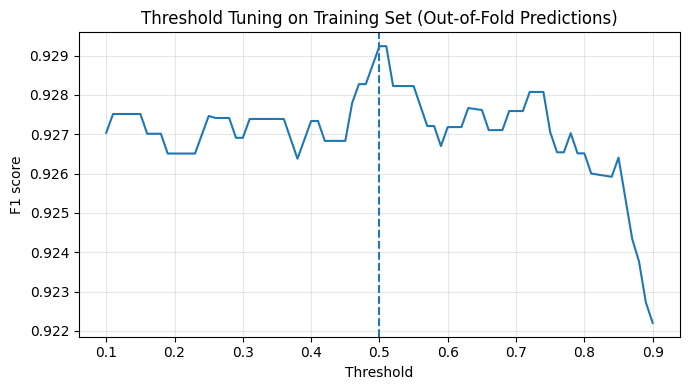

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold Tuning on Training Set (Out-of-Fold Predictions)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
final_model = best_grid.best_estimator_
final_model.fit(X_train_small, y_train_small)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [27]:
test_scores = final_model.predict_proba(X_test)[:, 1]

y_pred_default = (test_scores >= 0.50).astype(int)
y_pred_tuned = (test_scores >= best_threshold).astype(int)

print("Default threshold (0.50) accuracy:", round(accuracy_score(y_test, y_pred_default), 4))
print("Tuned threshold accuracy:        ", round(accuracy_score(y_test, y_pred_tuned), 4))
print()

print("ROC AUC:", round(roc_auc_score(y_test, test_scores), 4))
print("Average Precision (PR AUC summary):", round(average_precision_score(y_test, test_scores), 4))

Default threshold (0.50) accuracy: 0.94
Tuned threshold accuracy:         0.94

ROC AUC: 0.9479
Average Precision (PR AUC summary): 0.997


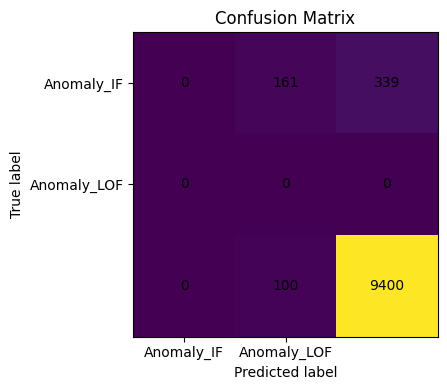

In [32]:
cm = confusion_matrix(y_test, y_pred_tuned)
plot_confusion_matrix_simple(cm, labels=("Anomaly_IF","Anomaly_LOF"))

In [40]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Normal", "Anomaly_IF", "Anomaly_LOF"]
))

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00       500
  Anomaly_IF       0.00      0.00      0.00         0
 Anomaly_LOF       0.97      0.99      0.98      9500

    accuracy                           0.94     10000
   macro avg       0.32      0.33      0.33     10000
weighted avg       0.92      0.94      0.93     10000



C:\Users\larin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\larin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\larin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

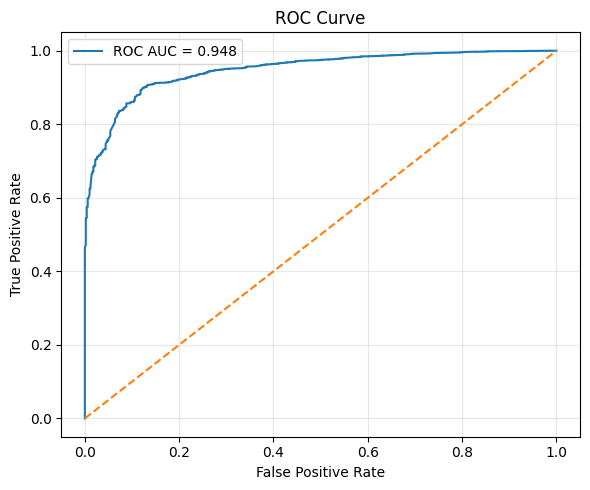

In [36]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

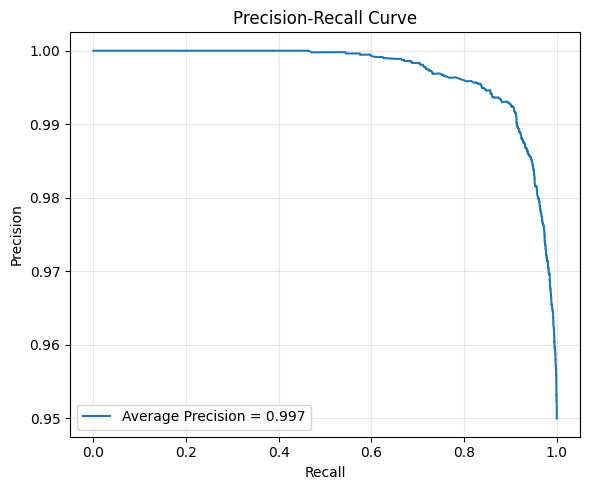

In [37]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_scores)
ap = average_precision_score(y_test, test_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

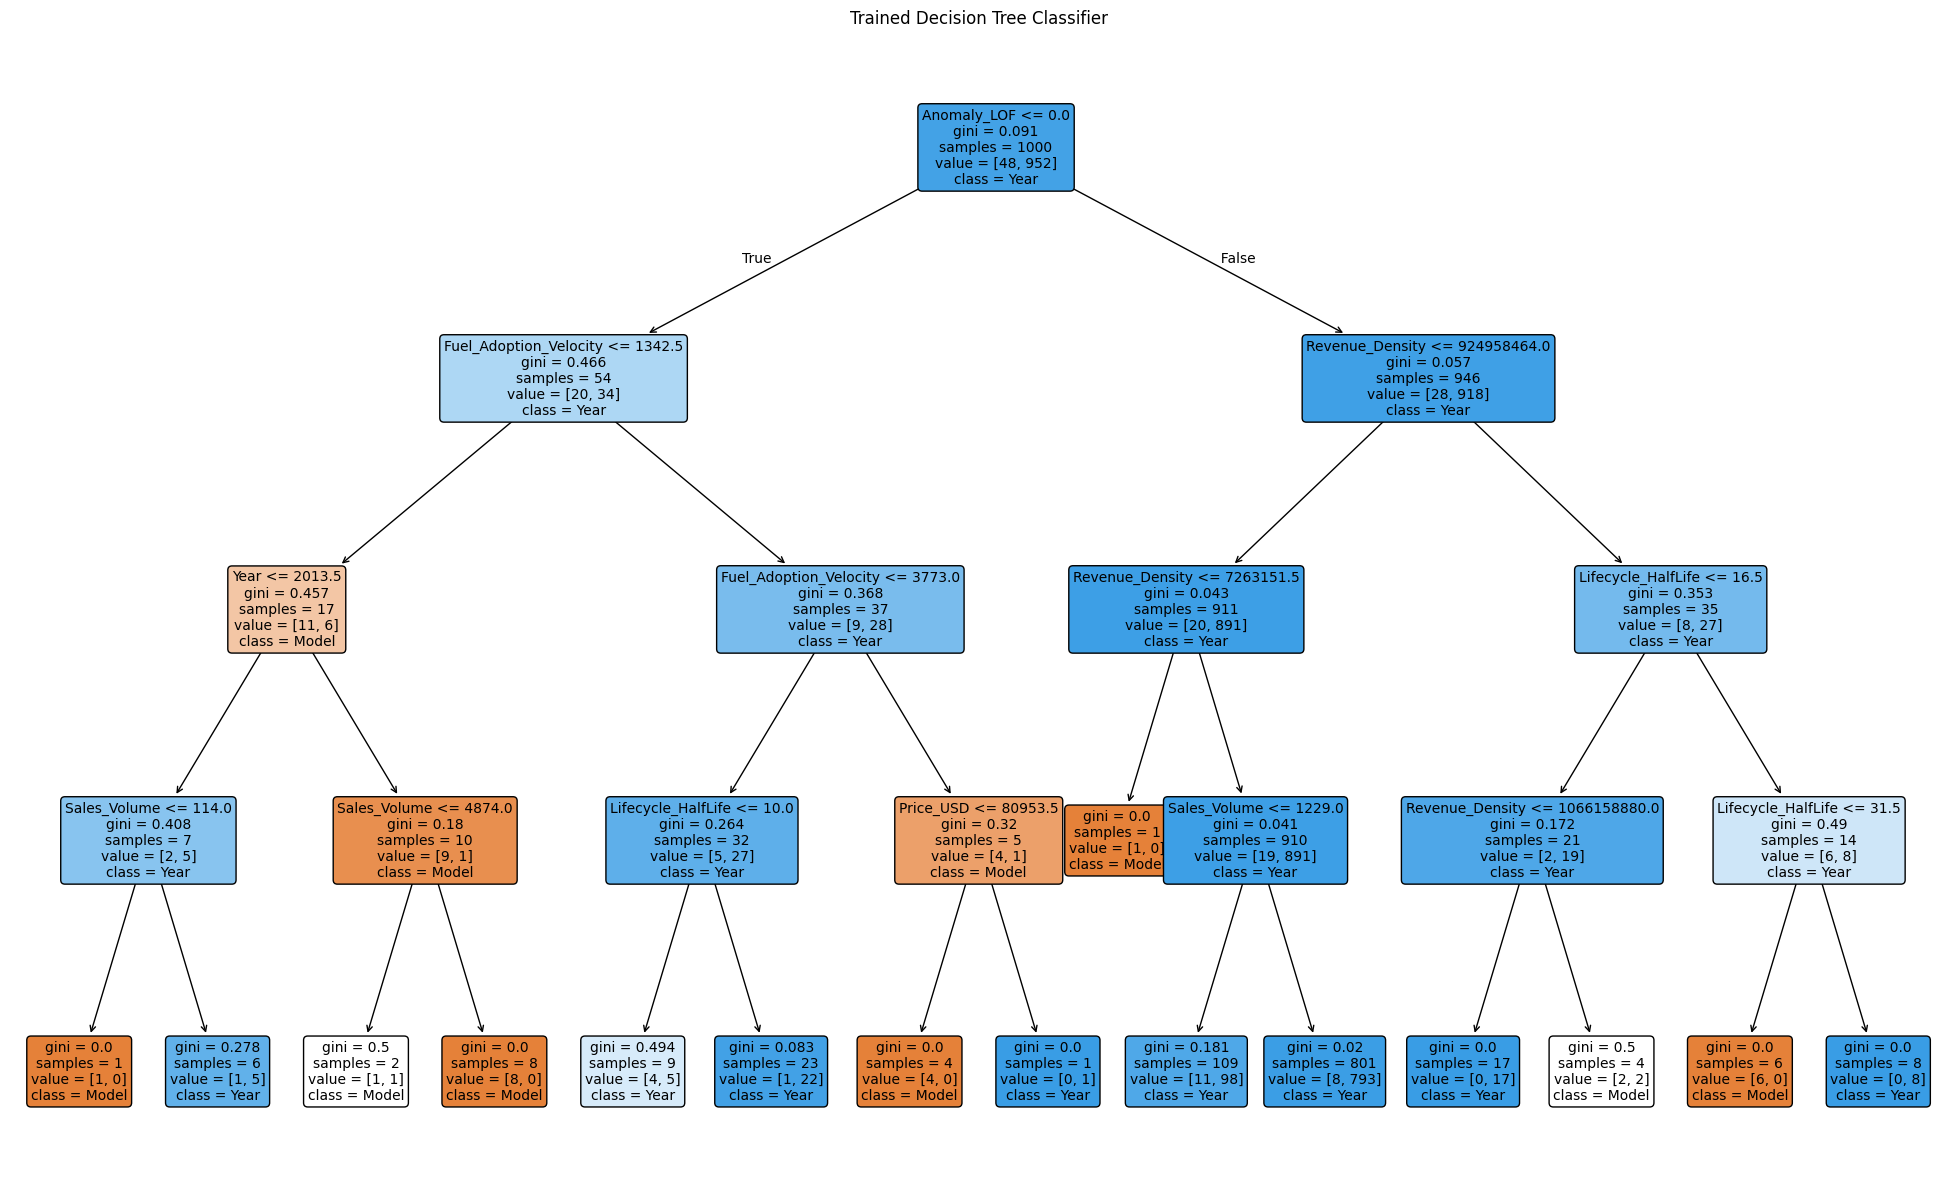

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the best Decision Tree estimator from the grid search
best_tree_model = tree_grid.best_estimator_

plt.figure(figsize=(25, 15))
plot_tree(best_tree_model, filled=True, feature_names=X.columns, class_names=bmw.columns, rounded=True, fontsize=10)
plt.title("Trained Decision Tree Classifier")
plt.show()